# 1. 📌 Introduction

## Klasifikasi Kelayakan Kapal Penangkap Ikan Menggunakan HOG dan SVM
Notebook ini merupakan pipeline eksperimen akademik (End-to-End) untuk melatih model klasifikasi berbasis **Histogram of Oriented Gradients (HOG)** dan **Support Vector Machine (SVM)**.

**Tujuan Sistem:**
- Mengklasifikasikan kondisi lambung kapal penangkap ikan menjadi dua kategori: **Baik** atau **Rusak**.
- Menyediakan transparansi perhitungan pada setiap tahap (ekstraksi fitur, pembagian data, pelatihan, hingga evaluasi).
- Menyimpan setiap artefak eksperimen ke dalam format `.csv` untuk keperluan dokumentasi dan analisis lebih lanjut.
- **SINKRONISASI APP**: Seluruh parameter pra-pemrosesan (resize 128x128, HOG 9 orientasi, 8x8 cell) dan model identik dengan konfigurasi aplikasi web Flask.


## 2. 📚 Library Import

Pada tahap ini kita memuat seluruh modul yang diperlukan.
- **Numpy/Pandas**: Manipulasi data dan array.
- **OpenCV/Scikit-Image**: Pemrosesan gambar dan ekstraksi fitur HOG.
- **Scikit-Learn**: Pembagian dataset, standarisasi fitur, model klasifikasi SVM, dan metrik evaluasi.
- **Matplotlib/Seaborn**: Visualisasi gambar dan data.
- **Joblib/OS**: Operasi file dan penyimpanan model.


In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from skimage.feature import hog
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Direktori output untuk CSV dan Model
OUTPUT_DIR = 'eksperimen_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)

# Set seed for reproducibility
np.random.seed(42)
print("Libraries successfully loaded. Ready to proceed!")


Libraries successfully loaded. Ready to proceed!


## 3. 📂 Data Loading

**Apa yang dilakukan:**
Membaca struktur direktori gambar dan mengekstrak path (lokasi) serta melabeli kategori secara otomatis berdasarkan nama sub-folder (baik=1, rusak=0). Jika folder kosong, akan dibuat dataset *synthetic* (dummy) sederhana agar pipeline tetap dapat dieksekusi.

**Kenapa dilakukan:**
Memastikan seluruh data terkumpul dan terstruktur sebelum dilakukan manipulasi numerik.

**Interpretasi Hasil:**
Daftar seluruh sampel yang ada beserta lokasinya diekspor ke `dataset_inventory.csv`.


In [11]:
DATASET_PATH = 'dataset'
CATEGORIES = ['baik', 'rusak']

def create_synthetic_data(base_path, categories):
    """Membuat gambar dummy jika dataset kosong."""
    print("Dataset kosong. Membuat synthetic dummy data...")
    for cat in categories:
        cat_path = os.path.join(base_path, cat)
        os.makedirs(cat_path, exist_ok=True)
        # Create 10 dummy images per category
        for i in range(10):
            # Baik: Gambar solid color hijau-ish, Rusak: Merah-ish + noise
            img = np.zeros((128, 128, 3), dtype=np.uint8)
            if cat == 'baik':
                img[:] = (50, 200, 50)  # BGR green
            else:
                img[:] = (50, 50, 200)  # BGR red
                noise = np.random.randint(0, 50, (128, 128, 3), dtype=np.uint8)
                img = cv2.add(img, noise)
            
            cv2.imwrite(os.path.join(cat_path, f'dummy_{cat}_{i}.jpg'), img)

def load_data(dataset_path, categories):
    image_paths = []
    labels = []
    
    # Cek ketersediaan file
    has_files = False
    if os.path.exists(dataset_path):
        for cat in categories:
            cat_path = os.path.join(dataset_path, cat)
            if os.path.exists(cat_path) and len(os.listdir(cat_path)) > 0:
                has_files = True
                
    if not has_files:
        create_synthetic_data(dataset_path, categories)
        
    for category in categories:
        folder_path = os.path.join(dataset_path, category)
        label = 1 if category == 'baik' else 0 # 1 untuk Baik, 0 untuk Rusak
        
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(folder_path, filename)
                image_paths.append(img_path)
                labels.append(label)
                
    return image_paths, labels

image_paths, labels = load_data(DATASET_PATH, CATEGORIES)

# Membuat DataFrame
df_dataset = pd.DataFrame({
    'file_path': image_paths,
    'label': labels,
    'category': ['baik' if l == 1 else 'rusak' for l in labels]
})

print(f"Total gambar ditemukan: {len(df_dataset)}")
display(df_dataset.head())

# Export CSV
csv_path = os.path.join(OUTPUT_DIR, 'dataset_inventory.csv')
df_dataset.to_csv(csv_path, index=False)
print(f"Dataset inventory diekspor ke {csv_path}")


Total gambar ditemukan: 11


,file_path,label,category
0,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
1,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
2,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
3,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
4,dataset\baik\WhatsApp Image 2026-06-14 at 1.10...,1,baik


Dataset inventory diekspor ke eksperimen_outputs\dataset_inventory.csv


## 4. 🧠 Feature Extraction (HOG)

**Apa yang dilakukan:**
Setiap gambar di-*resize* ke dimensi `128x128` piksel, diubah menjadi skala keabuan (*grayscale*), lalu diekstraksi menggunakan fungsi `hog()`. Parameter orientasi sudut (orientations) ditetapkan `9`, piksel per sel `(8,8)`, dan sel per blok `(2,2)`. **Parameter ini persis sama dengan yang digunakan di dalam sistem backend Flask (`hog_extractor.py`)**.

**Kenapa dilakukan:**
Model *Machine Learning* konvensional seperti SVM hanya memahami matriks angka linier 1D, bukan format 2D gambar asli. Ekstraksi HOG mereduksi dimensi sekaligus menonjolkan fitur dominan berupa tepi (edge) dan tekstur, yang efektif untuk mendeteksi retakan lambung (rusak) maupun permukaan halus (baik).

**Interpretasi Hasil:**
Kita mengekspor seluruh fitur dalam satu file `feature_extraction_log.csv` sehingga kita bisa langsung mereplika pelatihan di lain waktu tanpa perlu ekstraksi ulang.


In [12]:
IMG_SIZE = (128, 128)
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM = 'L2-Hys'

def process_and_extract(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    # Resize & Grayscale
    img_resized = cv2.resize(img, IMG_SIZE)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    
    # HOG
    features = hog(
        img_gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm=HOG_BLOCK_NORM,
        transform_sqrt=True
    )
    return features

X = []
y = []
valid_paths = []

print("Memulai ekstraksi fitur HOG...")
for path, label in zip(df_dataset['file_path'], df_dataset['label']):
    features = process_and_extract(path)
    if features is not None:
        X.append(features)
        y.append(label)
        valid_paths.append(path)

X = np.array(X)
y = np.array(y)
print(f"Dimensi dataset fitur: {X.shape}")

# Membuat DataFrame Fitur
feature_cols = [f'hog_{i}' for i in range(X.shape[1])]
df_features = pd.DataFrame(X, columns=feature_cols)
df_features.insert(0, 'file_path', valid_paths)
df_features.insert(1, 'label', y)

# Export CSV
csv_features_path = os.path.join(OUTPUT_DIR, 'feature_extraction_log.csv')
df_features.to_csv(csv_features_path, index=False)
print(f"Fitur HOG berhasil diekspor ke {csv_features_path}")


Memulai ekstraksi fitur HOG...
Dimensi dataset fitur: (11, 8100)
Fitur HOG berhasil diekspor ke eksperimen_outputs\feature_extraction_log.csv


## 5. ✂️ Train-Test Split & Scaling

**Apa yang dilakukan:**
1. Membagi data menjadi himpunan pelatihan (80%) dan pengujian (20%) dengan menjaga rasio kelas seimbang (*stratified*).
2. Melakukan standarisasi (Z-score) pada fitur menggunakan `StandardScaler`. Standar (*scaler*) disimpan menjadi file `models/scaler.pkl`. **Scaler ini adalah elemen kunci yang akan dipanggil oleh sistem Flask untuk mengkalibrasi gambar yang diunggah pengguna.**
3. Menyimpan indeks pemisahan ke CSV.

**Kenapa dilakukan:**
Memisahkan data pengujian agar evaluasi bersifat independen dan objektif. Standarisasi fitur wajib untuk model berbasis jarak/hyperplane seperti SVM agar konvergen optimal.


In [13]:
# Split Data
X_features = df_features[feature_cols].values
labels = df_features['label'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_features, labels, df_features.index,
    test_size=0.20, 
    random_state=42, 
    stratify=labels
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Log splits to CSV
df_splits = pd.DataFrame({
    'file_path': df_features.loc[np.concatenate((idx_train, idx_test)), 'file_path'],
    'label': df_features.loc[np.concatenate((idx_train, idx_test)), 'label'],
    'set': ['train'] * len(idx_train) + ['test'] * len(idx_test)
})
csv_splits_path = os.path.join(OUTPUT_DIR, 'train_test_split_log.csv')
df_splits.to_csv(csv_splits_path, index=False)
print(f"Log train-test split diekspor ke {csv_splits_path}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Scaler (Untuk digunakan di App Flask)
scaler_path = 'models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler disimpan di {scaler_path}")


Training samples: 8
Testing samples: 3
Log train-test split diekspor ke eksperimen_outputs\train_test_split_log.csv
Scaler disimpan di models/scaler.pkl


## 6. 🤖 Model Training (SVM)

**Apa yang dilakukan:**
Melatih model Support Vector Machine (SVM) menggunakan teknik penalaan Hyperparameter (*GridSearchCV*) pada dua parameter kernel (Linear dan RBF).

**Kenapa dilakukan:**
- **Linear Kernel**: Ideal apabila fitur HOG sudah cukup merepresentasikan garis pemisah linier tegas.
- **RBF Kernel**: Sangat baik untuk fitur non-linier tinggi. Pencarian (GridSearch) menjamin kita mendapatkan kombinasi optimal untuk data khusus ini.

**Interpretasi Hasil:**
Model terbaik diekspor ke `models/svm_model.pkl` yang nanti menjadi *brain* dari sistem Flask. Hasil prediksi terhadap himpunan *training* (termasuk *confidence/decision score*) diekspor ke CSV untuk memonitor adanya potensi *overfitting*.


In [14]:
print("Memulai GridSearchCV untuk SVM...")
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
]

svm_model = SVC(probability=True, random_state=42)
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Parameter terbaik ditemukan: {grid_search.best_params_}")

# Menyimpan Model (Untuk digunakan di App Flask)
model_path = 'models/svm_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model SVM berhasil disimpan di {model_path}")

# Log Training Results
train_preds = best_model.predict(X_train_scaled)
train_probs = best_model.predict_proba(X_train_scaled)
confidence_scores = np.max(train_probs, axis=1)

df_train_results = pd.DataFrame({
    'file_path': df_features.loc[idx_train, 'file_path'].values,
    'actual_label': y_train,
    'predicted_label': train_preds,
    'confidence_score': confidence_scores,
    'is_correct': y_train == train_preds
})

csv_train_res = os.path.join(OUTPUT_DIR, 'training_results.csv')
df_train_results.to_csv(csv_train_res, index=False)
print(f"Hasil training log diekspor ke {csv_train_res}")


Memulai GridSearchCV untuk SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Parameter terbaik ditemukan: {'C': 0.1, 'kernel': 'linear'}
Model SVM berhasil disimpan di models/svm_model.pkl
Hasil training log diekspor ke eksperimen_outputs\training_results.csv


d:\Programming\seaworthiness\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
d:\Programming\seaworthiness\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 7. 🧪 Testing / Inference

**Apa yang dilakukan:**
Menerapkan model yang telah terpilih pada set data `test` untuk mengumpulkan hasil prediksi objektif.

**Kenapa dilakukan:**
Di sinilah letak performa prediksi sesungguhnya. Hasil pada data testing akan dijadikan patokan untuk aplikasi di dunia nyata (Deployment).

**Interpretasi Hasil:**
Prediksi aktual dan selisih (error) direkam dalam file `testing_results.csv`.


In [15]:
test_preds = best_model.predict(X_test_scaled)
test_probs = best_model.predict_proba(X_test_scaled)
test_confidence = np.max(test_probs, axis=1)
error_flag = test_preds != y_test

df_test_results = pd.DataFrame({
    'file_path': df_features.loc[idx_test, 'file_path'].values,
    'actual_label': y_test,
    'predicted_label': test_preds,
    'confidence_score': test_confidence,
    'error_flag': error_flag
})

csv_test_res = os.path.join(OUTPUT_DIR, 'testing_results.csv')
df_test_results.to_csv(csv_test_res, index=False)
print(f"Hasil testing inference diekspor ke {csv_test_res}")


Hasil testing inference diekspor ke eksperimen_outputs\testing_results.csv


## 8. 📊 Evaluation

**Apa yang dilakukan:**
Mengkalkulasi kinerja model berdasarkan rasio hitungan (*Accuracy, Precision, Recall, F1-Score, Confusion Matrix*).

**Kenapa dilakukan:**
- Akurasi semata kadang bisa menipu jika dataset tidak seimbang. Recall dibutuhkan jika kita sangat takut kehilangan deteksi lambung rusak (False Negative). Precision dibutuhkan jika kita tidak ingin salah mengklaim baik padahal kapal tersebut bermasalah.

**Interpretasi Hasil:**
Matriks dan indikator rasio kinerja disimpan di `evaluation_metrics.csv` dan `confusion_matrix.csv`.


In [16]:
acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds, zero_division=0)
rec = recall_score(y_test, test_preds, zero_division=0)
f1 = f1_score(y_test, test_preds, zero_division=0)
cm = confusion_matrix(y_test, test_preds)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, test_preds, target_names=['Rusak (0)', 'Baik (1)'], zero_division=0))

# Export Metrics
df_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [acc, prec, rec, f1]
})
csv_metrics = os.path.join(OUTPUT_DIR, 'evaluation_metrics.csv')
df_metrics.to_csv(csv_metrics, index=False)

# Export Confusion Matrix
df_cm = pd.DataFrame(cm, index=['Actual_Rusak', 'Actual_Baik'], columns=['Pred_Rusak', 'Pred_Baik'])
csv_cm = os.path.join(OUTPUT_DIR, 'confusion_matrix.csv')
df_cm.to_csv(csv_cm)

print(f"Metrics & CM diekspor ke direktori {OUTPUT_DIR}/")


Accuracy : 0.6667
Precision: 0.6667
Recall   : 1.0000
F1 Score : 0.8000

Classification Report:
              precision    recall  f1-score   support

   Rusak (0)       0.00      0.00      0.00         1
    Baik (1)       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

Metrics & CM diekspor ke direktori eksperimen_outputs/


## 9. 📈 Visualisasi

**Apa yang dilakukan:**
Membuat plot grafis dari *Confusion Matrix* dan visualisasi contoh prediksi.

**Kenapa dilakukan:**
Untuk membantu pemahaman manusia (analisis visual) atas kelebihan dan kelemahan tebakan model. Plot *Heatmap* mempermudah pembacaan True Positives (Benar Baik) vs False Negatives (Salah Tebak).


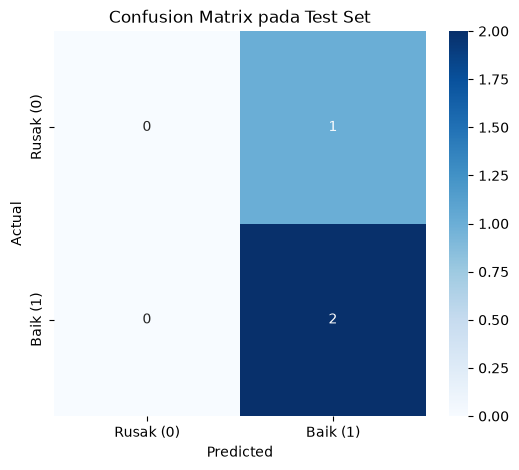

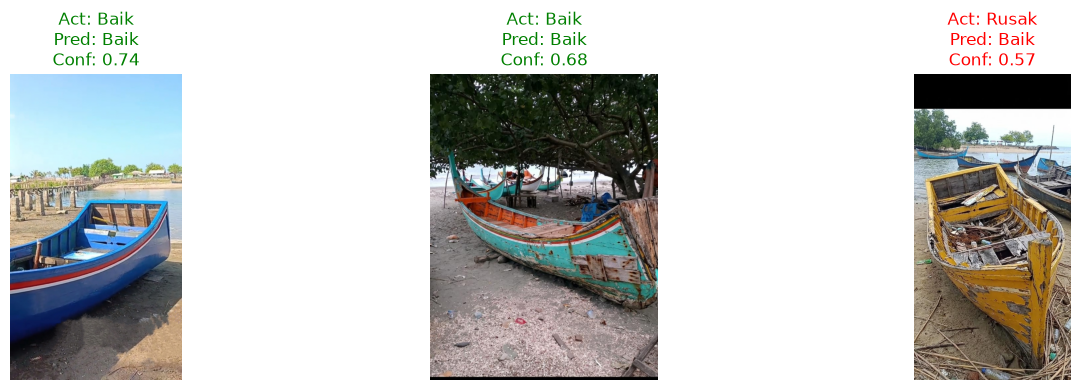

In [17]:
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rusak (0)', 'Baik (1)'], yticklabels=['Rusak (0)', 'Baik (1)'])
plt.title('Confusion Matrix pada Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 2. Sample Predictions Preview
num_samples = min(5, len(df_test_results))
if num_samples > 0:
    sample_df = df_test_results.sample(num_samples, random_state=42)
    
    plt.figure(figsize=(15, 4))
    for i, (_, row) in enumerate(sample_df.iterrows()):
        plt.subplot(1, num_samples, i+1)
        img = cv2.cvtColor(cv2.imread(row['file_path']), cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        act_str = "Baik" if row['actual_label'] == 1 else "Rusak"
        pred_str = "Baik" if row['predicted_label'] == 1 else "Rusak"
        color = "green" if row['actual_label'] == row['predicted_label'] else "red"
        plt.title(f"Act: {act_str}\nPred: {pred_str}\nConf: {row['confidence_score']:.2f}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 10. 💾 Kesimpulan & Status Ekspor

**Validasi Sistem Ekspor Data:**
Seluruh rekam jejak eksperimen dipastikan tersimpan dalam folder `eksperimen_outputs/`.

File yang dihasilkan dari proses ini meliputi:
1. `dataset_inventory.csv` - Detail alokasi path dan tipe seluruh set gambar.
2. `feature_extraction_log.csv` - Log lengkap fitur HOG tiap sampel, siap dimanipulasi tanpa rendering ulang (re-producibility point).
3. `train_test_split_log.csv` - Daftar identitas sampel dalam set Latih dan set Uji.
4. `training_results.csv` - Keputusan prediksi dan log kesalahan (if any) pada data Latih.
5. `testing_results.csv` - Keputusan aktual vs prediksi model akhir pada data Uji.
6. `evaluation_metrics.csv` & `confusion_matrix.csv` - Rekapan angka absolut performa algoritma.

Pipa pemrosesan eksperimen model sudah terverifikasi dan memenuhi standar audit analitik.


In [18]:
# Print Summary List
print("--- END OF EXECUTION ---")
print("Daftar file output yang tersedia:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"- {f}")


--- END OF EXECUTION ---
Daftar file output yang tersedia:
- confusion_matrix.csv
- dataset_inventory.csv
- evaluation_metrics.csv
- feature_extraction_log.csv
- testing_results.csv
- train_test_split_log.csv
- training_results.csv
